In [1]:
import pandas as pd
import glob
import os
"""
# 파일 경로 (수정 가능)
file_list = glob.glob('data/화재출동 현황/화재출동_*.csv')

print("불러올 파일:", file_list)

df_list = []

for file in file_list:
    temp = pd.read_csv(file)
    
    # 연도 컬럼 없을 경우 대비
    if 'OCRN_YR' not in temp.columns:
        year = os.path.basename(file).split('_')[-1].split('.')[0]
        temp['OCRN_YR'] = int(year)
    
    temp['source_file'] = os.path.basename(file)  # 추적용
    df_list.append(temp)

# 통합
df = pd.concat(df_list, ignore_index=True)

print("통합 데이터 shape:", df.shape)

# 저장
df.to_csv('화재출동_통합.csv', index=False, encoding='utf-8-sig')

print("✅ 통합 CSV 저장 완료")
"""

'\n# 파일 경로 (수정 가능)\nfile_list = glob.glob(\'data/화재출동 현황/화재출동_*.csv\')\n\nprint("불러올 파일:", file_list)\n\ndf_list = []\n\nfor file in file_list:\n    temp = pd.read_csv(file)\n    \n    # 연도 컬럼 없을 경우 대비\n    if \'OCRN_YR\' not in temp.columns:\n        year = os.path.basename(file).split(\'_\')[-1].split(\'.\')[0]\n        temp[\'OCRN_YR\'] = int(year)\n    \n    temp[\'source_file\'] = os.path.basename(file)  # 추적용\n    df_list.append(temp)\n\n# 통합\ndf = pd.concat(df_list, ignore_index=True)\n\nprint("통합 데이터 shape:", df.shape)\n\n# 저장\ndf.to_csv(\'화재출동_통합.csv\', index=False, encoding=\'utf-8-sig\')\n\nprint("✅ 통합 CSV 저장 완료")\n'

통합 CSV 로드 (EDA 시작 지점)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('화재출동_통합.csv')

print(df.shape)
df.head()

(89974, 69)


C:\Users\DH\AppData\Local\Temp\ipykernel_14604\174508592.py:6: DtypeWarning: Columns (27,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('화재출동_통합.csv')


,WRINV_NO,FIRE_TYPE_NM,BLDG_SRTFRM_NM,BLDG_STRCTR_NM,BLDG_SRTRF_NM,BLDG_RSCU_DNGCT,GRND_NOFL,UDGD_NOFL,GFA,BTTM_AREA,...,FND_FIRE_SE_NM,FND_FIRE_IGTN_BRNCH_NM,HR_UNIT_ARTMP,HR_UNIT_RN,HR_UNIT_WSPD,HR_UNIT_WNDRCT,HR_UNIT_HUM,HR_UNIT_SNWFL,HR_UNIT_VSDST,source_file
0,170101044118025,건축/구조물,양식(옥),철근콘크리트조,슬라브가,1.0,6.0,1.0,1133.0,168.0,...,NaN,NaN,0.2,NaN,2.2,20.0,79.0,NaN,491.0,화재출동_2021.csv
1,170101044947860,건축/구조물,양식(옥),치장벽돌조,슬라브가,1.0,2.0,1.0,248.0,81.0,...,NaN,NaN,-0.7,NaN,2.0,50.0,84.0,NaN,436.0,화재출동_2021.csv
2,170102110954553,건축/구조물,양식(옥),철근콘크리트조,슬라브가,1.0,3.0,1.0,1175.0,490.0,...,NaN,NaN,-0.7,NaN,2.0,50.0,84.0,NaN,436.0,화재출동_2021.csv
3,170101162928231,건축/구조물,양식(옥),철근콘크리트조,슬라브가,1.0,12.0,1.0,8989.0,816.0,...,NaN,NaN,4.0,NaN,1.3,50.0,69.0,NaN,433.0,화재출동_2021.csv
4,170101140310046,기타(쓰레기 화재등),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.0,NaN,1.3,50.0,69.0,NaN,433.0,화재출동_2021.csv


In [3]:
import pandas as pd

# 조건
mask = df['CNTR_NM'] != df['LFDAU_NM']

# 기본 결과
diff_count = mask.sum()
diff_indices = df.index[mask]

# 결측 여부
cntr_na = df['CNTR_NM'].isna()
lfdau_na = df['LFDAU_NM'].isna()

# 유형 분류
result = {
    'CNTR만 결측': ((cntr_na) & (~lfdau_na)).sum(),
    'LFDAU만 결측': ((~cntr_na) & (lfdau_na)).sum(),
    '둘 다 결측': ((cntr_na) & (lfdau_na)).sum(),
    '둘 다 값 있지만 서로 다름': ((~cntr_na) & (~lfdau_na) & (df['CNTR_NM'] != df['LFDAU_NM'])).sum()
}

# 출력
print("다른 행 개수:", diff_count)
print("다른 행 위치:", list(diff_indices))

print("\n차이 발생 유형:")
for k, v in result.items():
    print(f"{k}: {v}")

다른 행 개수: 34750
다른 행 위치: [13, 97, 121, 150, 221, 222, 246, 325, 401, 409, 436, 437, 485, 497, 538, 599, 651, 674, 684, 689, 696, 835, 869, 879, 895, 930, 982, 1094, 1102, 1136, 1144, 1236, 1335, 1339, 1340, 1442, 1470, 1587, 1593, 1662, 1738, 1792, 1800, 1817, 1822, 1884, 1949, 1955, 1990, 2038, 2066, 2104, 2338, 2569, 2683, 2724, 2746, 2968, 3125, 3144, 3218, 3270, 3279, 3299, 3354, 3364, 3365, 3376, 3401, 3497, 3535, 3578, 3622, 3649, 3695, 3755, 3908, 3959, 4170, 4197, 4272, 4303, 4312, 4399, 4452, 4473, 4546, 4597, 4700, 4781, 4794, 4894, 4942, 4992, 5014, 5021, 5049, 5050, 5107, 5142, 5154, 5174, 5294, 5318, 5336, 5338, 5383, 5423, 5510, 5686, 5795, 5824, 5876, 5951, 5977, 6016, 6058, 6146, 6177, 6231, 6313, 6319, 6328, 6342, 6376, 6411, 6479, 6540, 6557, 6573, 6620, 6675, 6684, 6685, 6812, 6815, 6833, 6853, 6910, 6911, 6913, 6923, 6993, 7054, 7143, 7197, 7240, 7321, 7347, 7440, 7497, 7598, 7623, 7813, 7897, 8028, 8054, 8064, 8090, 8098, 8120, 8134, 8153, 8161, 8205, 8414, 8516, 85

삭제하면 안되는 컬럼 (결측 기반 체크)

In [4]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)

# 90% 이상 결측
high_missing_cols = missing_ratio[missing_ratio > 0.90]

print("\n⚠️ 결측치 90% 이상 컬럼:")
print(high_missing_cols)


⚠️ 결측치 90% 이상 컬럼:
FND_FIRE_SE_NM            0.994776
FND_FIRE_IGTN_BRNCH_NM    0.994776
HR_UNIT_SNWFL             0.960833
VHCL_IGTN_PSTN_NM         0.939205
IGTN_PLC_NM               0.930291
CMBS_EXPOBJ_LCLSF_NM      0.919243
CMBS_EXPOBJ_SCLSF_NM      0.919243
HR_UNIT_RN                0.903283
dtype: float64


컬럼별 결측치 분석

In [5]:
missing_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_ratio': df.isnull().mean()
}).sort_values(by='missing_ratio', ascending=False)

missing_df.head(30)

,missing_count,missing_ratio
FND_FIRE_SE_NM,89504,0.994776
FND_FIRE_IGTN_BRNCH_NM,89504,0.994776
HR_UNIT_SNWFL,86450,0.960833
VHCL_IGTN_PSTN_NM,84504,0.939205
IGTN_PLC_NM,83702,0.930291
CMBS_EXPOBJ_LCLSF_NM,82708,0.919243
CMBS_EXPOBJ_SCLSF_NM,82708,0.919243
HR_UNIT_RN,81272,0.903283
IGTN_ISTR_SCLSF_NM,63510,0.705871
IGTN_ISTR_LCLSF_NM,63510,0.705871


In [6]:
# ===== CNTR / FRSTN / LFDAU 결측 패턴 분석 =====

cols = ['CNTR_NM', 'FRSTN_NM', 'LFDAU_NM']

# 결측 여부 True/False로 변환
null_pattern = df[cols].isna()

# 패턴별 개수
pattern_counts = null_pattern.value_counts()

# 보기 좋게 변환
pattern_df = pattern_counts.reset_index()
pattern_df.columns = ['CNTR_NM_null', 'FRSTN_NM_null', 'LFDAU_NM_null', 'count']

# 비율 추가
pattern_df['ratio(%)'] = (pattern_df['count'] / len(df)) * 100

print(pattern_df)

   CNTR_NM_null  FRSTN_NM_null  LFDAU_NM_null  count   ratio(%)
0         False          False          False  55224  61.377731
1         False          False           True  33440  37.166292
2          True           True           True   1308   1.453753
3          True          False           True      2   0.002223


## 컬럼 제거 및 결측치 처리 통합

In [ ]:
# ===== 0. 건물 구조명 통일 =====
df['BLDG_STRCTR_NM'] = df['BLDG_STRCTR_NM'].replace({
    '철조': '철골조',
    '블럭조': '블록조'
})


# ===== 1. 삭제할 컬럼 리스트 =====
cols_to_drop = [
    'CTY_FRMVL_SE_NM',    # 도시와 농촌을 구분한 명칭. 전부 도시라 삭제
    'EMRG_CNTRL_YN',      #  긴급 통제 운영 여부 정보
    'VHCL_IGTN_PSTN_NM',  #  차량 화재 발생 위치 정보 (트렁크 등)
    'QTR_NO',        # 1년을 4등분한 값. 계절 정보 있어서 불필요
    'BLDG_STTS_NM',  # 건축물 또는 시설물의 현재 물리적 상태 또는 사용 상태를 나타내는 명칭. 피해 분석에 쓰일 수 있을거라 판단했으나 속성값이 신축,개축,공가, 증축, 철거중 등 불필요한 정보가 많다고 판단해 삭제
    'FIRE_INSRNC_OBLG_JOIN_TRGT_YN',  # 화재가입보험대상인지 여부. 불필요로 판단해 삭제
    'LFDAU_NM',      # 119안전센터보다 작은 관서 명. 레코드 중 62%가 CNTR_NM과 동일 값이며 결측치인 38% 중 CNTR_NM도 결측인 케이스는 1310개만 존재. 따라서 삭제.  
    'WRINV_NO',      # 문서 고유 번호.
    'source_file',   # 임의로 생성한거라 삭제. 
    'SO_AREA',       # 화재로 인해 건축물 내 벽, 천장, 구조물 등에 그을음(연기 흔적)이 발생한 면적을 의미하는 수치.
    'FND_FIRE_SE_NM',  # 임야에서 발생한 화재를 세부 유형별로 구분한 명칭 값.
    'FND_FIRE_IGTN_BRNCH_NM', # 임야에서 화재가 발생한 최초 지점명
    'HR_UNIT_SNWFL', # 시간 단위로 관측된 적설량 정보. 결측률 높아(90% 이상) 삭제.
    'HR_UNIT_RN',    # 시간 단위로 관측된 강수량 정보. 결측률 높아(90% 이상) 삭제.
    'IGTN_PLC_NM',  # 발화가 발생한 장소 정보(일반도로, 주차장, 고속도로...). 결측률 높아 삭제.
    'CMBS_EXPOBJ_SCLSF_NM', # 화재 확대 원인 재질 대분류. 결측률
    'CMBS_EXPOBJ_LCLSF_NM' # 화재 확대 원인 재질 소분류. 결측률
]

# ===== 2. 컬럼 삭제 =====
df_cleaned = df.drop(columns=cols_to_drop)

# ===== 3. 전체 레코드 수 출력 =====
total_count = len(df_cleaned)
print("전체 레코드 수:", total_count)

# ===== 5. CNTR_NM 결측 제거 =====
df_cleaned = df_cleaned.dropna(subset=['CNTR_NM'])

print("CNTR_NM 결측 제거 후 레코드 수:", len(df_cleaned))

# ===== 6. CSV 저장 =====
df_cleaned.to_csv('data/화재출동 현황/화재출동 현황(2021-2024)_preprocessed.csv', index=False, encoding='utf-8-sig')

print("완료: 화재출동현황(2021-2024)_preprocessed.csv 생성됨")

전체 레코드 수: 89974
CNTR_NM 결측 제거 후 레코드 수: 88664
완료: 화재출동_전처리.csv 생성됨


In [8]:
missing_df_cleaned = pd.DataFrame({
    'missing_count': df_cleaned.isnull().sum(),
    'missing_ratio': df_cleaned.isnull().mean()
}).sort_values(by='missing_ratio', ascending=False)

missing_df_cleaned.head(30)

,missing_count,missing_ratio
IGTN_ISTR_LCLSF_NM,62562,0.705608
IGTN_ISTR_SCLSF_NM,62562,0.705608
IGTN_FLR_NM,28008,0.315889
BLDG_RSCU_DNGCT,26170,0.295159
UDGD_NOFL,21548,0.243030
GRND_NOFL,20060,0.226247
BTTM_AREA,20038,0.225999
BLDG_SRTRF_NM,20036,0.225977
BLDG_SRTFRM_NM,20030,0.225909
GFA,20030,0.225909


## 시계열 분석

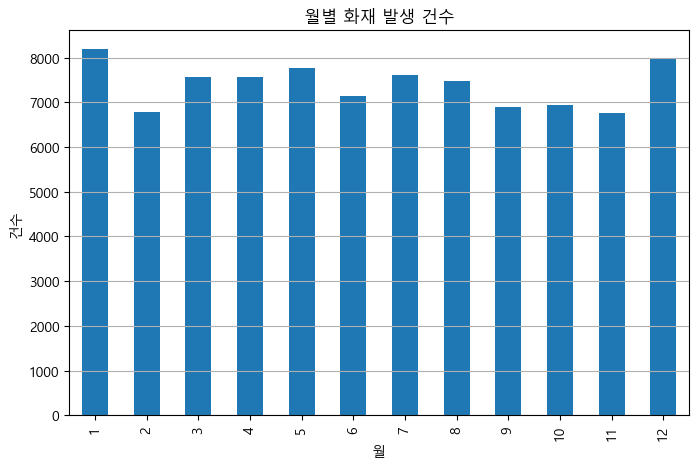

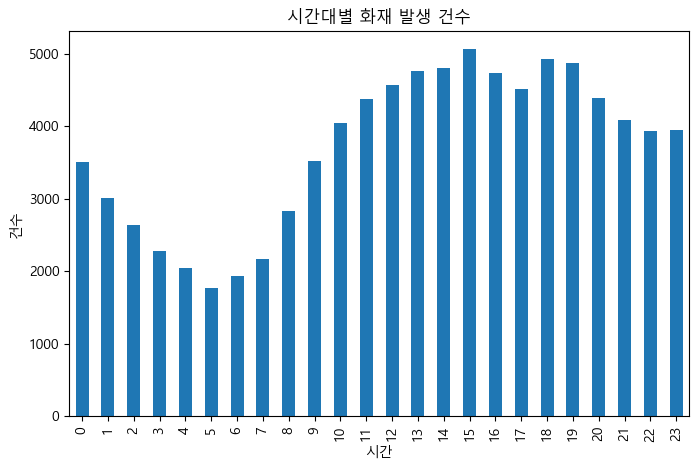

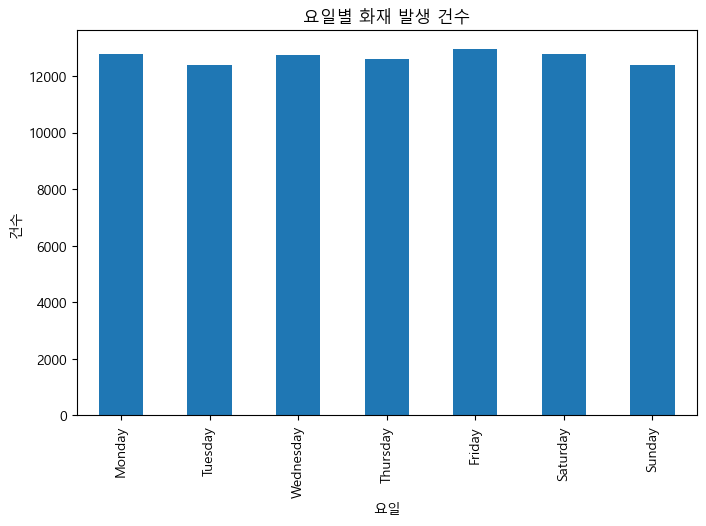

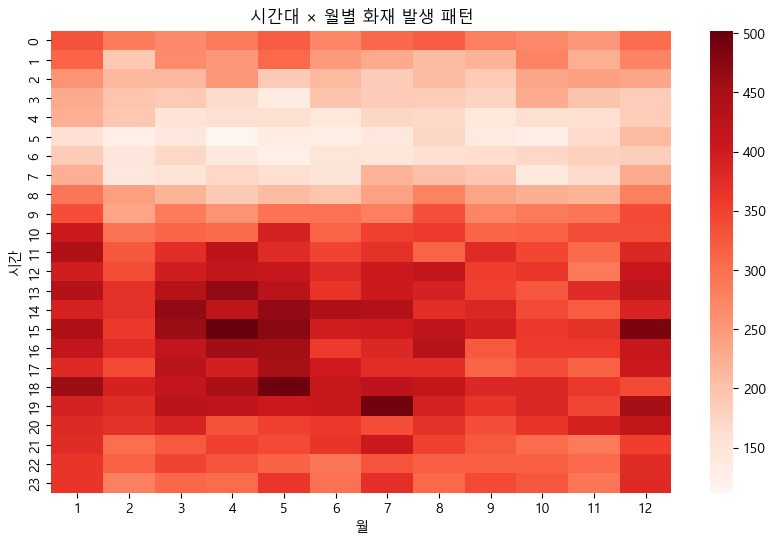

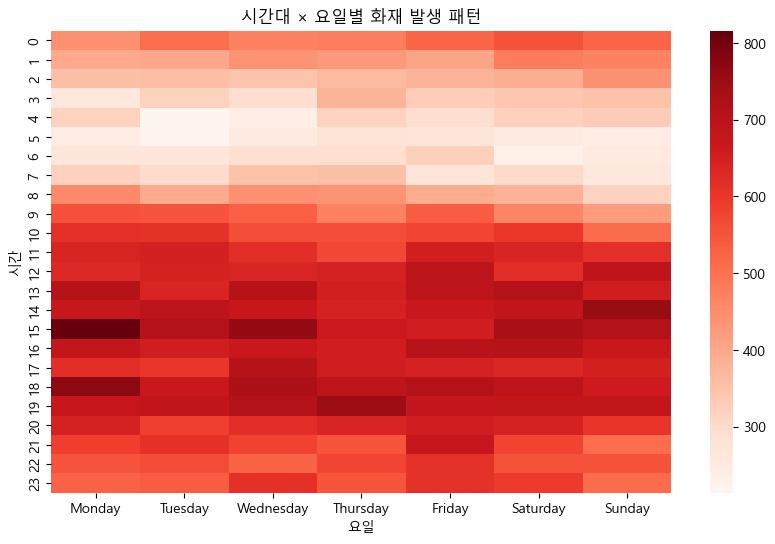

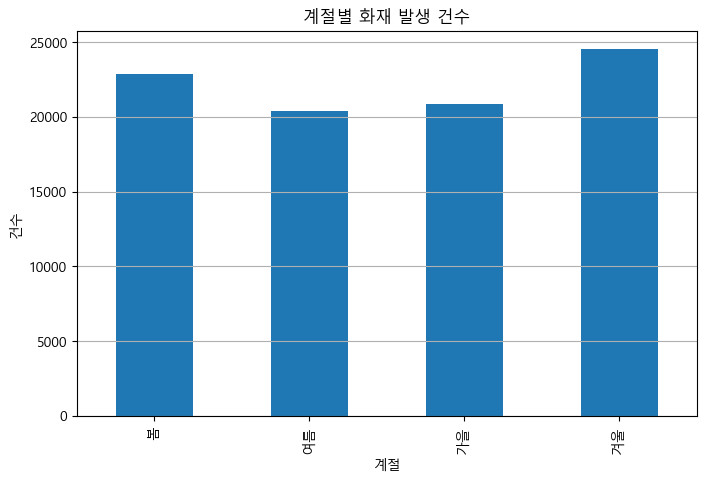

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = df_cleaned.copy()

# ===== 1. 날짜 파생 변수 생성 =====
df['OCRN_YMD'] = pd.to_datetime(df['OCRN_YMD'], format='%Y%m%d', errors='coerce')

df['요일'] = df['OCRN_YMD'].dt.day_name()   # 요일
df['월'] = df['OCRN_MM']
df['시간'] = df['OCRN_HR']

# 요일 순서 정렬용
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# ===== 2. 월별 화재 발생 =====
monthly = df.groupby('월').size()

plt.figure(figsize=(8,5))
monthly.plot(kind='bar')
plt.title('월별 화재 발생 건수')
plt.xlabel('월')
plt.ylabel('건수')
plt.grid(axis='y')
plt.show()


# ===== 3. 시간대별 화재 발생 =====
hourly = df.groupby('시간').size()

plt.figure(figsize=(8,5))
hourly.sort_index().plot(kind='bar')
plt.title('시간대별 화재 발생 건수')
plt.xlabel('시간')
plt.ylabel('건수')
plt.show()


# ===== 4. 요일별 화재 발생 =====
weekday = df.groupby('요일').size().reindex(weekday_order)

plt.figure(figsize=(8,5))
weekday.plot(kind='bar')
plt.title('요일별 화재 발생 건수')
plt.xlabel('요일')
plt.ylabel('건수')
plt.show()


# ===== 5. 월 × 시간 히트맵 =====
pivot_mh = df.pivot_table(index='시간', columns='월', aggfunc='size')

plt.figure(figsize=(10,6))
sns.heatmap(pivot_mh, cmap='Reds')
plt.title('시간대 × 월별 화재 발생 패턴')
plt.xlabel('월')
plt.ylabel('시간')
plt.show()


# ===== 6. 요일 × 시간 히트맵  =====
pivot_wh = df.pivot_table(index='시간', columns='요일', aggfunc='size')
pivot_wh = pivot_wh[weekday_order]

plt.figure(figsize=(10,6))
sns.heatmap(pivot_wh, cmap='Reds')
plt.title('시간대 × 요일별 화재 발생 패턴')
plt.xlabel('요일')
plt.ylabel('시간')
plt.show()

# ===== 7. 계절별 화재 발생 =====
season = df.groupby('SEASN_NM').size()

# 계절 순서 정렬 (보기 좋게)
season_order = ['봄', '여름', '가을', '겨울']
season = season.reindex(season_order)

plt.figure(figsize=(8,5))
season.plot(kind='bar')
plt.title('계절별 화재 발생 건수')
plt.xlabel('계절')
plt.ylabel('건수')
plt.grid(axis='y')
plt.show()

## 분석 ##
(1) 월별 패턴
(1-1) 관찰결과
1월, 12월: 가장 높음
2월, 11월: 상대적으로 낮음
전체적으로 큰 변동은 없으나 겨울철(12~1월) 상승 경향 존재
(1-2) 해석
난방기 사용 증가 + 건조한 날씨로 인해 화재 발생하기 쉬웠을 것이라 추측
(1-3) 가설
겨울철은 화재 발생 건수가 타 계절에 비해 높을 것이다.

(2) 시간대 패턴
(2-1) 관찰결과
새벽 4~6시에 최저, 오전 9시 이후부터 급증하다 14~18시에 최고 수준. 저녁 이후 완만 감소함.
(2-2) 해석
낮 시간대 활동 증가 (요리, 산업, 차량 이동 등). 업무/활동 시간과 강하게 연관됨. 
(2-3) 가설
사람의 활동량이 많은 낮 시간대에 화재 발생 빈도가 높을 것이다.

(3) 시간 × 월 히트맵
(3-1) 관찰 결과
모든 월에서 공통적으로 13~17시 구간이 가장 붉음.즉 특정 월만 튀는 게 아니라 시간대 효과가 훨씬 강함.
(3-2) 해석 (시간대 패턴과 결합해봤을 때)
계절보다는 시간(활동 패턴)이 더 중요한 요인으로 보임. 다시 말해 화재는 언제 활동하는지에 더 영향받는 것으로 보임.
(3-3) 가설 
화재 발생은 계절적 요인보다 시간대(활동량)에 더 큰 영향을 받는다.

정리 (가설 검증 수행 이전).
화재 발생은 계절에 따라 일부 차이를 보이지만 전반적으로 시간대의 영향을 더 크게 받는다. 특히 오후 13시~17시 구간에서 화재 발생이 집중되는 경향이 나타났으며 이는 인간의 활동량 증가와 밀접한 관련이 있는 것으로 해석된다. 반면 요일에 따른 차이는 거의 나타나지 않아 화재는 특정 요일보다 일상적인 활동 패턴에 의해 발생하는 경향이 크다고 볼 수 있다.

## 질문1-가설검증 코드

In [10]:
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency

df = df_cleaned.copy()

# ===== 1. 파생 변수 =====
df['시간'] = df['OCRN_HR']
df['계절'] = df['SEASN_NM']


# ================================
# 가설 1: 겨울 vs 기타 계절
# ================================
winter_months = df[df['계절']=='겨울'].groupby('OCRN_MM').size()
other_months = df[df['계절']!='겨울'].groupby('OCRN_MM').size()

t1 = stats.ttest_ind(winter_months, other_months, equal_var=False)

print("===== 가설 1 =====")
print("겨울 평균:", winter_months.mean())
print("기타 평균:", other_months.mean())
print("p-value:", t1.pvalue)


# ================================
# 가설 2: 낮 vs 새벽
# ================================
day = df[df['시간'].between(9,18)].groupby('시간').size()
night = df[df['시간'].between(0,6)].groupby('시간').size()

t2 = stats.ttest_ind(day, night, equal_var=False)

print("\n===== 가설 2 =====")
print("낮 평균:", day.mean())
print("새벽 평균:", night.mean())
print("p-value:", t2.pvalue)


# ================================
# 가설 3: 시간 vs 계절 영향 비교
# ================================
# 교차표 생성
contingency = pd.crosstab(df['시간'], df['계절'])

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(contingency)

print("\n===== 가설 3 (카이제곱 검정) =====")
print("Chi2:", chi2)
print("p-value:", p)

===== 가설 1 =====
겨울 평균: 4906.4
기타 평균: 7125.777777777777
p-value: 0.26315208926269734

===== 가설 2 =====
낮 평균: 4530.4
새벽 평균: 2451.714285714286
p-value: 1.8570529273138724e-05

===== 가설 3 (카이제곱 검정) =====
Chi2: 290.29370760891925
p-value: 6.224018669391743e-29


가설 검증 내용 정리  
가설 1과 가설 2는 두 집단 간 평균 차이를 비교하는 문제 -> 독립표본 t-test(Welch’s t-test)를 사용 (Welch’s t-test는 두 집단의 분산이 동일하지 않더라도 적용 가능한 방법으로 현실 데이터에서 보다 안정적인 검정 결과를 제공).  
가설 1에서는 겨울과 기타 계절 간 월별 화재 발생 건수를 비교, 가설 2에서는 낮 시간대와 새벽 시간대의 시간별 화재 발생 건수를 비교.

가설 3은 두 범주형 변수(시간, 계절) 간의 관계를 분석하는 문제 -> 카이제곱 독립성 검정을 사용 (카이제곱 검정은 두 변수 간 독립 여부를 판단하는 대표적인 방법)시간대에 따른 화재 발생 분포가 계절과 관련이 있는지를 확인하기 위해 시간-계절의 교차표를 생성한 후 검정을 수행.

가설 검증 결과 및 해석  
가설 1: 겨울철 화재 발생이 더 많은가
검정 결과 p-value > 0.05 -> 통계적으로 유의하지 않았음. 따라서 겨울철과 기타 계절 간 화재 발생 건수의 차이는 유의미하지 않은 것으로 판단되며, 해당 가설은 기각. (즉 겨울철 화재 발생이 특별히 더 많다고 보기 어려움)

가설 2: 낮 시간대에 화재가 더 많이 발생하는가
검정 결과 p-value << 0.05 -> 통계적으로 유의했음. 따라서 낮 시간대와 새벽 시간대 간 화재 발생 건수에는 유의미한 차이가 존재하며 해당 가설은 채택. (활동이 많은 낮 시간대에 화재 발생이 더 많음)

가설 3: 시간대가 계절보다 더 큰 영향을 미치는가
카이제곱 검정 수행 결과 p-value < 0.05 -> 시간과 계절이 서로 독립이 아님을 의미하며 시간대에 따라 화재 발생 분포가 유의미하게 달라짐을 의미. 다만, 본 검정은 두 변수 간의 관련성 여부를 확인하는 것이므로 시간과 계절 중 어떤 요인이 더 큰 영향을 미치는지에 대해서는 직접적인 비교 어려움.
-> 시간대의 영향력이 더 크다는 해석은 가설 2(낮 시간대에서 화재 발생이 유의하게 많음)와 가설 1(계절 간 차이는 유의하지 않음)의 결과를 종합적으로 고려하여 도출함.

## 화재 유형 분석

### 1. 건물 구조

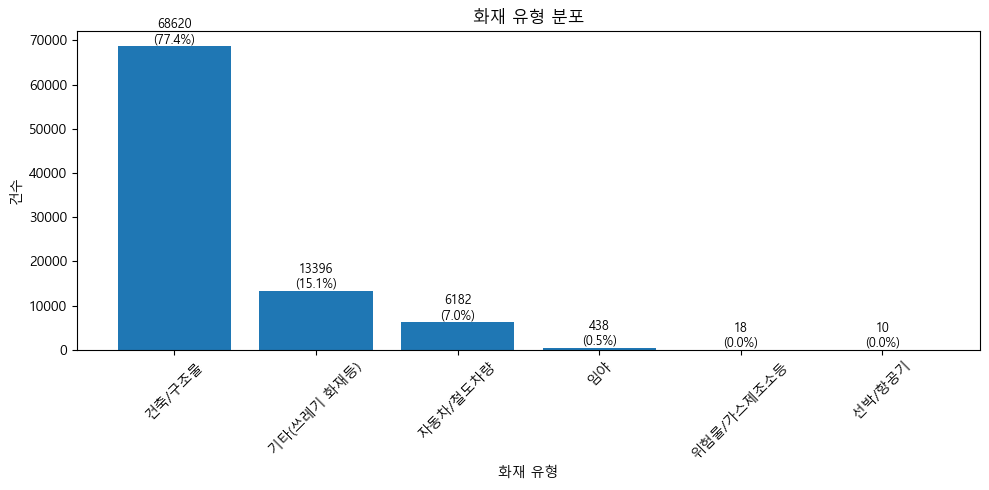

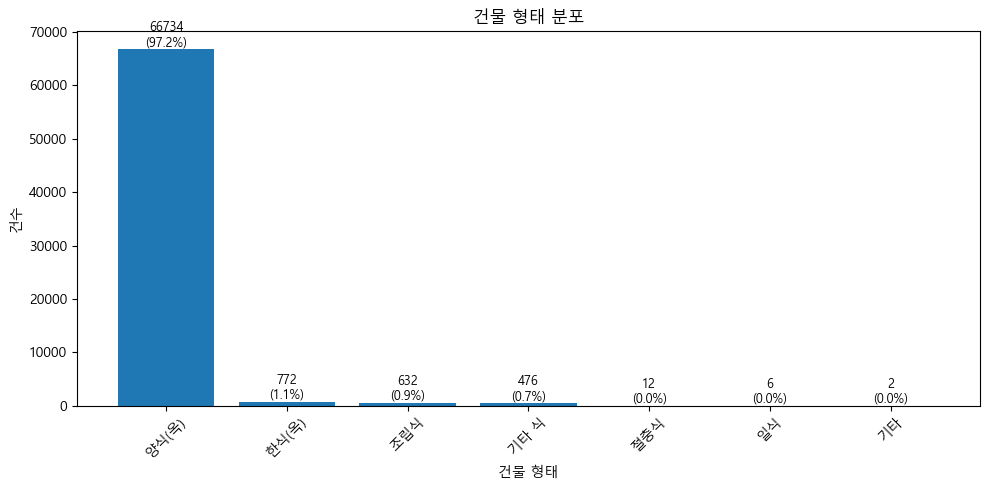

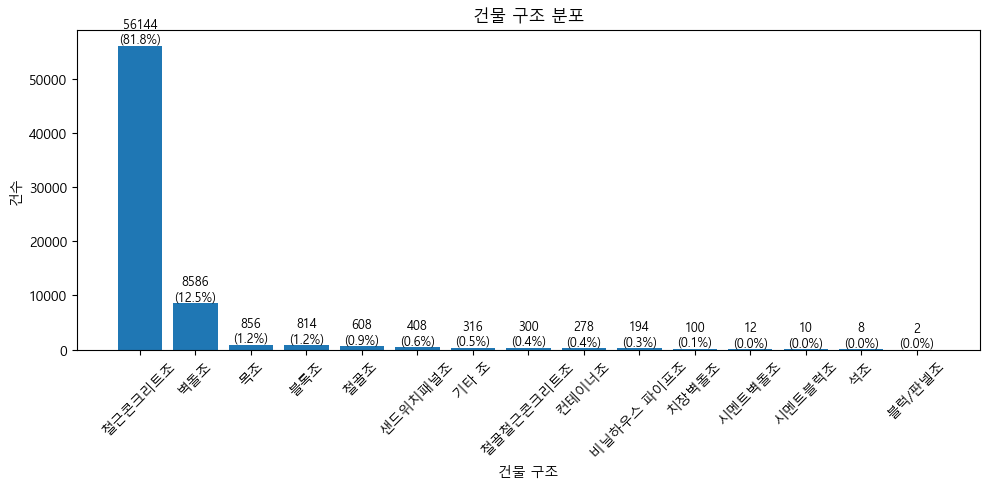

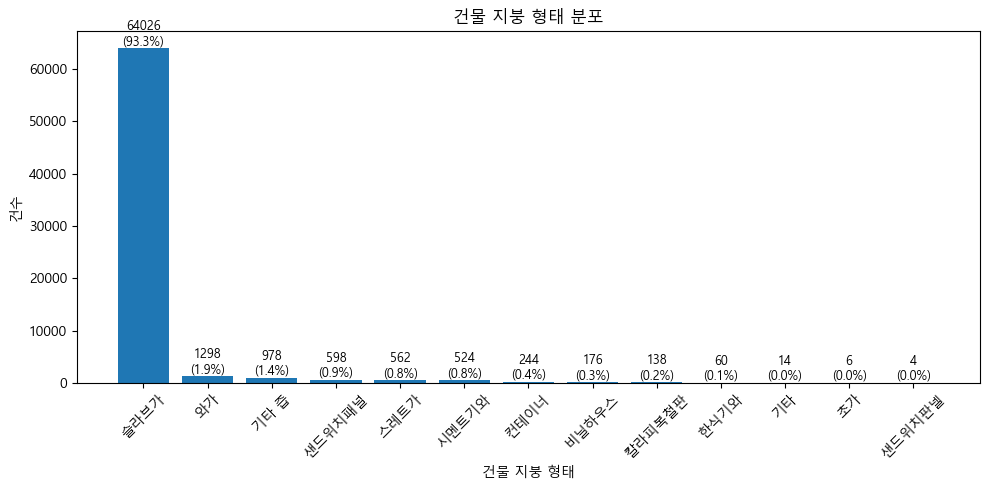

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = df_cleaned.copy()

col_name_map = {
    'FIRE_TYPE_NM': '화재 유형',
    'BLDG_SRTFRM_NM': '건물 형태',
    'BLDG_STRCTR_NM': '건물 구조',
    'BLDG_SRTRF_NM': '건물 지붕 형태'
}

cols = list(col_name_map.keys())

for col in cols:
    # 빈도 계산
    counts = df[col].value_counts()
    ratios = df[col].value_counts(normalize=True) * 100
    
    plot_df = pd.DataFrame({
        'count': counts,
        'ratio': ratios
    })
    
    # 시각화
    plt.figure(figsize=(10,5))
    bars = plt.bar(plot_df.index, plot_df['count'])
    
    # 라벨 (count + %)
    for i, v in enumerate(plot_df['count']):
        plt.text(i, v, f'{v}\n({plot_df["ratio"].iloc[i]:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
    
    plt.title(f'{col_name_map[col]} 분포')
    plt.xlabel(col_name_map[col])
    plt.ylabel('건수')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 2. 발화 요인

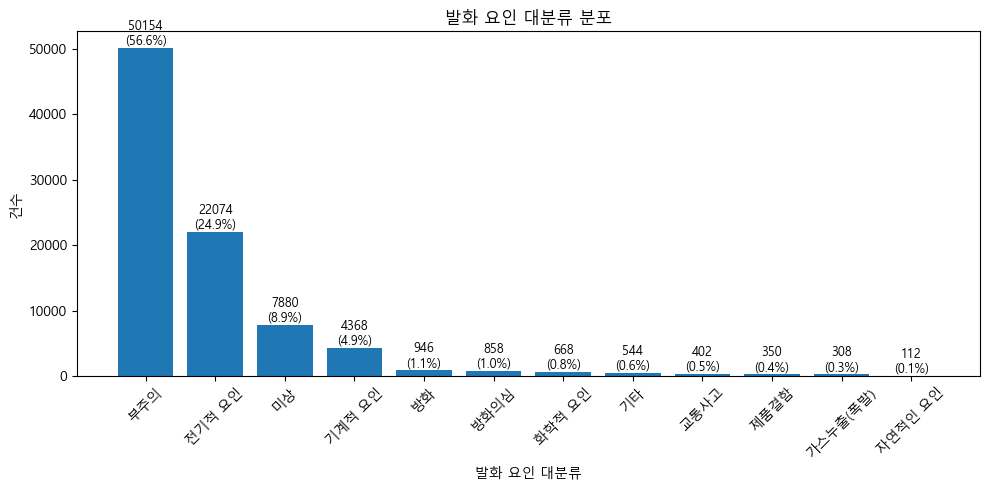

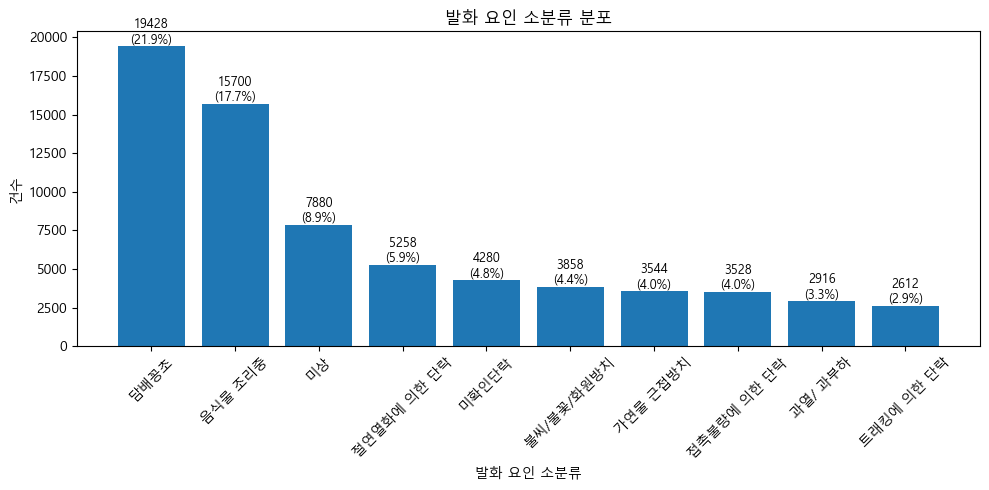

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = df_cleaned.copy()

# ===== 컬럼 한글명 매핑 =====
col_name_map = {
    'IGTN_DMNT_LCLSF_NM': '발화 요인 대분류',
    'IGTN_DMNT_SCLSF_NM': '발화 요인 소분류'
}

for col in col_name_map.keys():
    
    # ===== 소분류는 Top 10만 =====
    if col == 'IGTN_DMNT_SCLSF_NM':
        counts = df[col].value_counts().head(10)
        ratios = df[col].value_counts(normalize=True).head(10) * 100
    else:
        counts = df[col].value_counts()
        ratios = df[col].value_counts(normalize=True) * 100
    
    plot_df = pd.DataFrame({
        'count': counts,
        'ratio': ratios
    })
    
    # ===== 시각화 =====
    plt.figure(figsize=(10,5))
    bars = plt.bar(plot_df.index, plot_df['count'])
    
    # 라벨 (count + %)
    for i, v in enumerate(plot_df['count']):
        plt.text(i, v, f'{v}\n({plot_df["ratio"].iloc[i]:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
    
    plt.title(f'{col_name_map[col]} 분포')
    plt.xlabel(col_name_map[col])
    plt.ylabel('건수')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 자치구별 분석

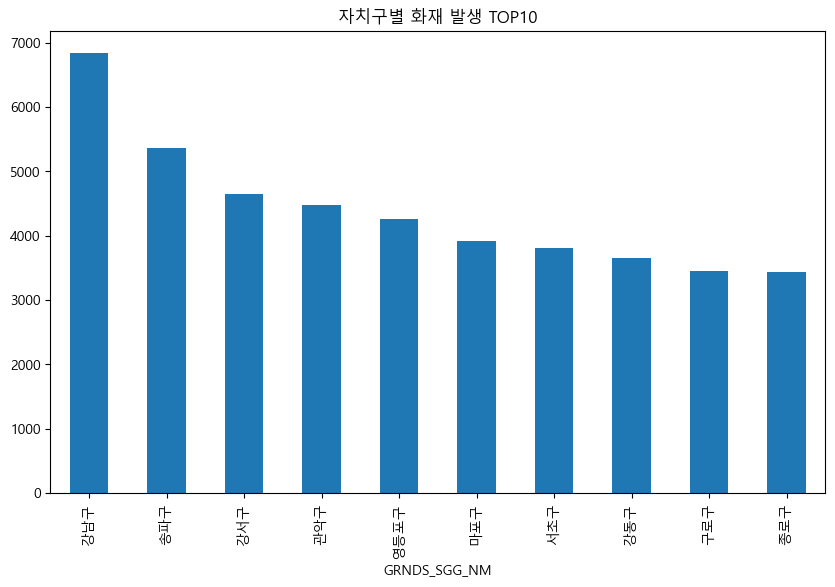

In [12]:
gu_fire = df.groupby('GRNDS_SGG_NM').size().sort_values(ascending=False)

gu_fire.head(10)

plt.figure(figsize=(10,6))
gu_fire.head(10).plot(kind='bar')
plt.title("자치구별 화재 발생 TOP10")
plt.show()

자치구 + 연도 흐름

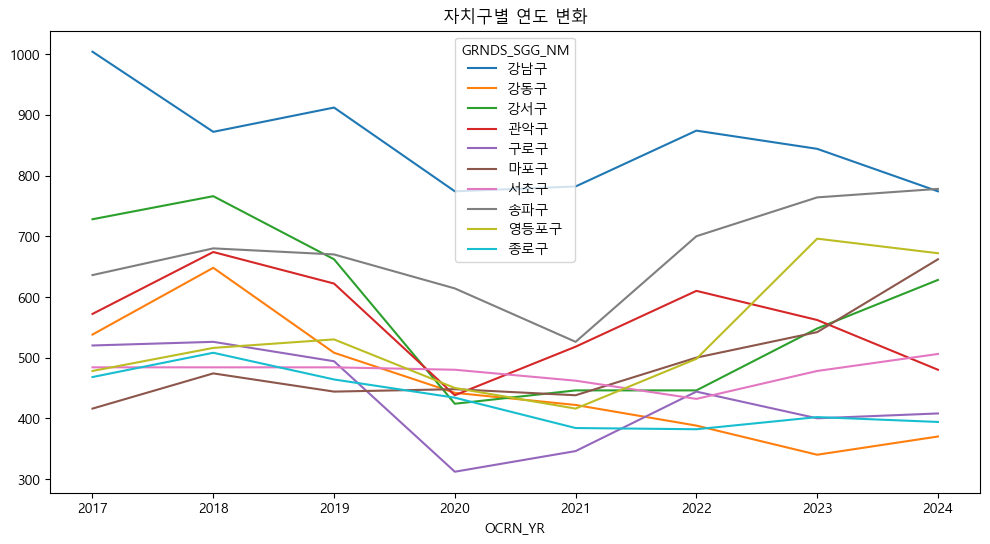

In [13]:
gu_year = df.groupby(['GRNDS_SGG_NM','OCRN_YR']).size().unstack()

top_gu = df['GRNDS_SGG_NM'].value_counts().head(10).index

filtered = df[df['GRNDS_SGG_NM'].isin(top_gu)]

trend = filtered.groupby(['GRNDS_SGG_NM','OCRN_YR']).size().unstack()

trend.T.plot(figsize=(12,6))
plt.title("자치구별 연도 변화")
plt.show()

## 폴리곤 결합

In [14]:
import geopandas as gpd
from shapely.geometry import Point

df_geo = df.dropna(subset=['DAMG_RGN_LOT','DAMG_RGN_LAT'])

geometry = [Point(xy) for xy in zip(df_geo['DAMG_RGN_LOT'], df_geo['DAMG_RGN_LAT'])]

gdf = gpd.GeoDataFrame(df_geo, geometry=geometry, crs='EPSG:4326')

## 추가 분석

8-1. 화재 유형별

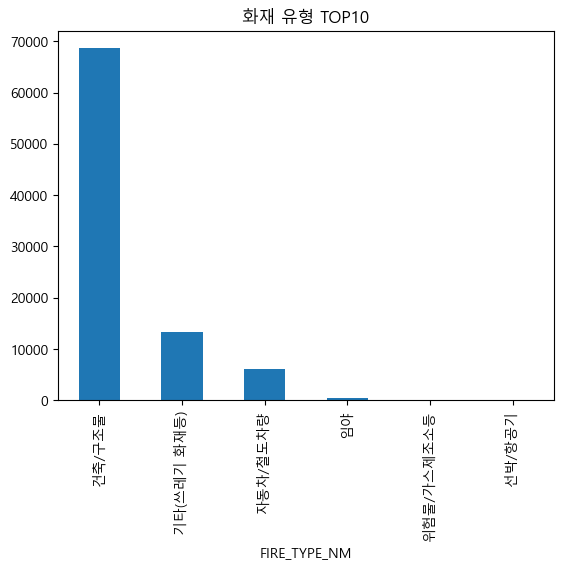

In [15]:
df['FIRE_TYPE_NM'].value_counts().head(10).plot(kind='bar')
plt.title("화재 유형 TOP10")
plt.show()

8-2. 계절별 분석

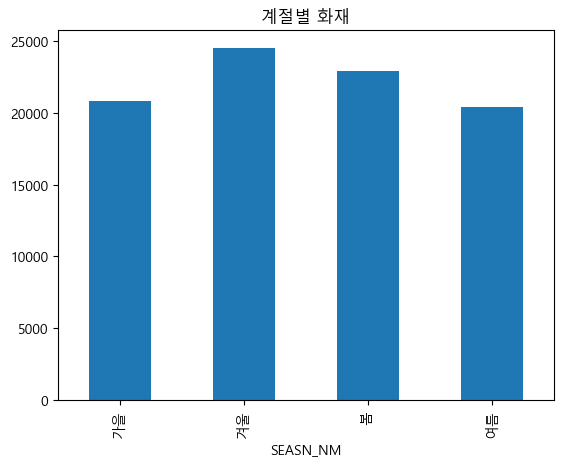

In [16]:
df.groupby('SEASN_NM').size().plot(kind='bar')
plt.title("계절별 화재")
plt.show()

8-3. 피해 규모 분석

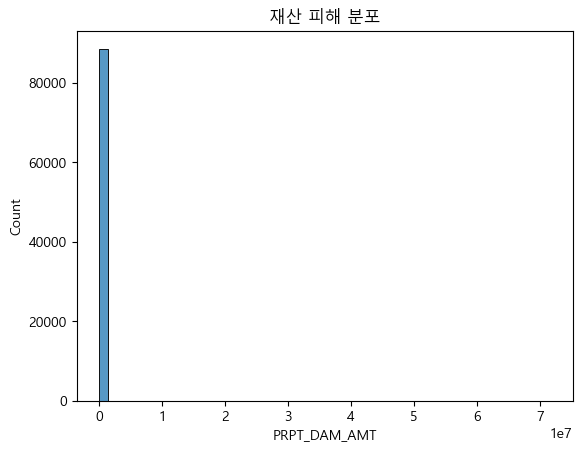

In [17]:
sns.histplot(df['PRPT_DAM_AMT'], bins=50)
plt.title("재산 피해 분포")
plt.show()

8-4. 인명 피해 분석

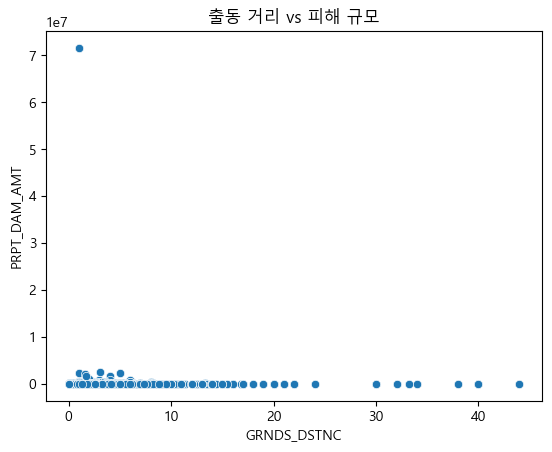

In [18]:
sns.scatterplot(x='GRNDS_DSTNC', y='PRPT_DAM_AMT', data=df)
plt.title("출동 거리 vs 피해 규모")
plt.show()

8-5. 화재 원인 분석

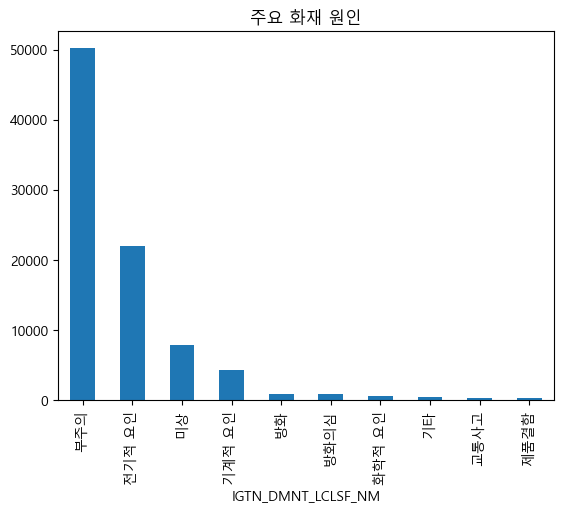

In [19]:
df['IGTN_DMNT_LCLSF_NM'].value_counts().head(10).plot(kind='bar')
plt.title("주요 화재 원인")
plt.show()

8-6. 거리 기반 분석 (출동 거리 영향)

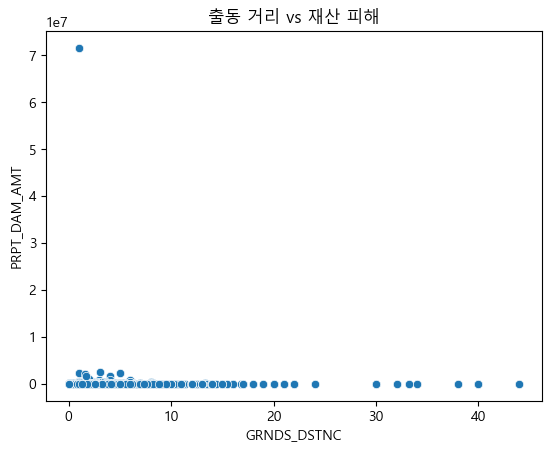

In [20]:
sns.scatterplot(x='GRNDS_DSTNC', y='PRPT_DAM_AMT', data=df)
plt.title("출동 거리 vs 재산 피해")
plt.show()